 # <font color="CE4A06">Artificial Neural Network (ANN) With 'Heart Failure' Dataset</font>

&nbsp;  
Again, we will use the 'heart_failure_clinical_records_dataset' in this lesson.

&nbsp;   
**Attribute information:**  
- age: age of the patient (years)
- anaemia: decrease of red blood cells or hemoglobin (0/1)
- high blood pressure: if the patient has hypertension (0/1)
- creatinine phosphokinase (CPK): level of the CPK enzyme in the blood (mcg/L)
- diabetes: if the patient has diabetes (0/1)
- ejection fraction: percentage of blood leaving the heart at each contraction (percentage)
- platelets: platelets in the blood (kiloplatelets/mL)
- sex: female or male (0=Female/1=Male)
- serum creatinine: level of serum creatinine in the blood (mg/dL)
- serum sodium: level of serum sodium in the blood (mEq/L)
- smoking: if the patient smokes or not (0/1)
- time: follow-up period (days)
- survive<sup>*</sup>: if the patient deceased during the follow-up period (0/1)

<sup>*</sup>Outcome variable/Label

&nbsp;  
<font color="275bb0">**Read dataset**</font>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/ThammakornS/ProgStat/main/dataset/heart_failure_clinical_records_dataset.csv")
df.head(10)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,survive
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,0
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,0
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,0
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,0
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,0
5,90.0,1,47,0,40,1,204000.00,2.1,132,1,1,8,0
6,75.0,1,246,0,15,0,127000.00,1.2,137,1,0,10,0
7,60.0,1,315,1,60,0,454000.00,1.1,131,1,1,10,0
8,65.0,0,157,0,65,0,263358.03,1.5,138,0,0,10,0
9,80.0,1,123,0,35,1,388000.00,9.4,133,1,1,10,0


&nbsp;    
<font color="275bb0">**Adjust data type**</font>

In [4]:
df = df.astype({
    'survive': 'category',
})

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   age                       299 non-null    float64 
 1   anaemia                   299 non-null    int64   
 2   creatinine_phosphokinase  299 non-null    int64   
 3   diabetes                  299 non-null    int64   
 4   ejection_fraction         299 non-null    int64   
 5   high_blood_pressure       299 non-null    int64   
 6   platelets                 299 non-null    float64 
 7   serum_creatinine          299 non-null    float64 
 8   serum_sodium              299 non-null    int64   
 9   sex                       299 non-null    int64   
 10  smoking                   299 non-null    int64   
 11  time                      299 non-null    int64   
 12  survive                   299 non-null    category
dtypes: category(1), float64(3), int64(9)
memory usage:

&nbsp;  
Class 1: survive  
Class 0: not survive

In [6]:
df.survive.value_counts()

survive
1    203
0     96
Name: count, dtype: int64

&nbsp;  
<font color="275bb0">**Separate data and label**</font>

X: Data (features)  
y: Label (outcome)

In [7]:
X = df.loc[:,'age':'time']
print(X.shape)
X.head()

(299, 12)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8


In [8]:
y = df.survive
print(y.shape)
y

(299,)


0      0
1      0
2      0
3      0
4      0
      ..
294    1
295    1
296    1
297    1
298    1
Name: survive, Length: 299, dtype: category
Categories (2, int64): [0, 1]

&nbsp;  
<font color="275bb0">**Train-test split**</font>

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.3,
                                                    random_state=0)

\
Reset all indices to start from 0 to avoid further confusion.

In [10]:
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

&nbsp;  
Training set:

In [11]:
X_train.shape

(209, 12)

In [12]:
y_train.value_counts()

survive
1    141
0     68
Name: count, dtype: int64

&nbsp;  
Test set:

In [13]:
X_test.shape

(90, 12)

In [14]:
y_test.value_counts()

survive
1    62
0    28
Name: count, dtype: int64

&nbsp;  
<font color="275bb0">**Feature data scaling**</font>

\
We can use std() to infer data scale in each column:

In [15]:
df.std(numeric_only=True)

age                            11.894809
anaemia                         0.496107
creatinine_phosphokinase      970.287881
diabetes                        0.494067
ejection_fraction              11.834841
high_blood_pressure             0.478136
platelets                   97804.236869
serum_creatinine                1.034510
serum_sodium                    4.412477
sex                             0.478136
smoking                         0.467670
time                           77.614208
dtype: float64

&nbsp;  
Performing feature data scaling:

In [16]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(X_train)

MinMaxScaler()

&nbsp;  
Scale training set:

In [17]:
X_train_sc = scaler.transform(X_train)
X_train_sc = pd.DataFrame(X_train_sc, columns=X_train.columns)

In [18]:
X_train_sc.std(numeric_only=True)

age                         0.215009
anaemia                     0.497602
creatinine_phosphokinase    0.127765
diabetes                    0.497001
ejection_fraction           0.233453
high_blood_pressure         0.480815
platelets                   0.123246
serum_creatinine            0.109068
serum_sodium                0.145281
sex                         0.479378
smoking                     0.464016
time                        0.280701
dtype: float64

&nbsp;  
Scale test set:

In [19]:
X_test_sc = scaler.transform(X_test)
X_test_sc = pd.DataFrame(X_test_sc, columns=X_test.columns)

In [20]:
X_test_sc.std(numeric_only=True)

age                         0.232880
anaemia                     0.494792
creatinine_phosphokinase    0.114649
diabetes                    0.487548
ejection_fraction           0.273957
high_blood_pressure         0.474045
platelets                   0.107486
serum_creatinine            0.132003
serum_sodium                0.118637
sex                         0.477849
smoking                     0.477849
time                        0.282332
dtype: float64

&nbsp;  
#### <font color="166e20">*Setup ANN Models*</font>

Class MLPClassifier implements a multi-layer perceptron (MLP) algorithm that trains using Backpropagation.  
***MLP requires tuning a number of hyperparameters such as the number of hidden neurons, layers, and iterations.***

hidden_layer_sizes: tuple, length = n_layers - 2, **default=(100,)**:
- The i<sup>th</sup> element represents the number of neurons in the ith hidden layer.    
  
activation: activation{‘identity’, ‘logistic’, ‘tanh’, ‘relu’}, **default=’relu’**
Activation function for the hidden layer:  
- ‘identity’, no-op activation, useful to implement linear bottleneck, returns f(x) = x
- ‘logistic’, the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).
- ‘tanh’, the hyperbolic tan function, returns f(x) = tanh(x).
- ‘relu’, the rectified linear unit function, returns f(x) = max(0, x)  
  
solver{‘lbfgs’, ‘sgd’, ‘adam’}, **default=’adam’**:
- ‘lbfgs’ is an optimizer in the family of quasi-Newton methods.
- ‘sgd’ refers to stochastic gradient descent.
- ‘adam’ refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy Ba  
Note: The default solver ‘adam’ works pretty well on relatively large datasets (with thousands of training samples or more) in terms of both training time and validation score. For small datasets, however, ‘lbfgs’ can converge faster and perform better.

learning_rate_initfloat, **default=0.001**:
- The initial learning rate used. It controls the step-size in updating the weights. Only used when solver=’sgd’ or ‘adam’.  
  
learning_rate{‘constant’, ‘invscaling’, ‘adaptive’}, **default=’constant’**:
- ‘constant’ is a constant learning rate given by ‘learning_rate_init’.
- ‘invscaling’ gradually decreases the learning rate at each time step ‘t’ using an inverse scaling exponent of ‘power_t’. effective_learning_rate = learning_rate_init / pow(t, power_t)
- ‘adaptive’ keeps the learning rate constant to ‘learning_rate_init’ as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if ‘early_stopping’ is on, the current learning rate is divided by 5.  
  
max_iter, **default=200**:
- Maximum number of iterations. The solver iterates until convergence (determined by ‘tol’) or this number of iterations. For stochastic solvers (‘sgd’, ‘adam’), note that this determines the number of epochs (how many times each data point will be used), not the number of gradient steps.
  
batch_size, **default=’auto’**:
- Size of minibatches for stochastic optimizers. If the solver is ‘lbfgs’, the classifier will not use minibatch. When set to “auto”, batch_size=min(200, n_samples).
  
For more information:  
https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html#sklearn.neural_network.MLPClassifier

In [21]:
# This have 3 hidden layers, 1st have 24 neurons, 2nd have 12 neurons, 3rd have 6 neurons
# Not have the best layer it depended on the dataset
from sklearn.neural_network import MLPClassifier
ann = MLPClassifier(hidden_layer_sizes=(24, 12, 6),
                    activation='relu',
                    solver='adam',
                    random_state=1234, # random number generation for weights and bias initialization
                    learning_rate='adaptive',
                    max_iter = 200, # number of epoch -> ยิ่ง Epoch เยอะ ก็ยิ่งใช้เวลานาน และไม่ได้การันตีว่ายิ่งมากยิ่งได้ผลลัพธ์ที่นิ่ง
                    # batch_size = 25
                   )

&nbsp;  
#### <font color="166e20">*Using Cross-Validation Techniques*</font>

\
Configure cv:

In [22]:
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5,
                      shuffle=True,
                      random_state=1234)

In [23]:
from sklearn.model_selection import cross_val_predict
y_pred = cross_val_predict(estimator=ann,
                           X=X_train_sc,
                           y=y_train,
                           cv=skf)

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\User\AppDa

\
Display confusion matrix:

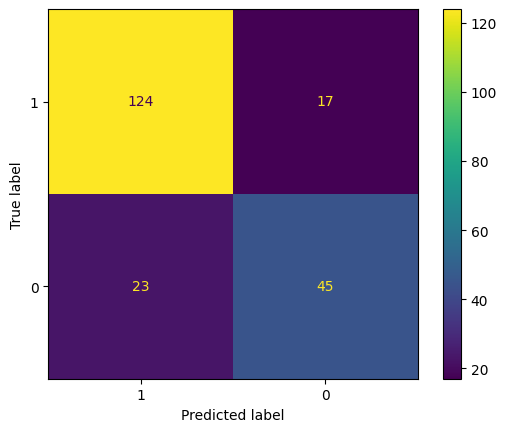

In [24]:
conf_mat = metrics.confusion_matrix(y_train, y_pred, labels=[1,0])
metrics.ConfusionMatrixDisplay(conf_mat,
                               display_labels=[1,0]).plot()

\
Get performance scores:

In [25]:
acc = metrics.accuracy_score(y_train, y_pred)
precision = metrics.precision_score(y_train, y_pred)
recall = metrics.recall_score(y_train, y_pred)
f1 = metrics.f1_score(y_train, y_pred)
auc = metrics.roc_auc_score(y_train, y_pred)

print(f"acc={acc:.2f}")
print(f"precision={precision:.2f}")
print(f"recall={recall:.2f}")
print(f"f1={f1:.2f}")
print(f"auc={auc:.2f}")

acc=0.81
precision=0.84
recall=0.88
f1=0.86
auc=0.77


&nbsp;  
#### <font color="166e20">*Choosing Hidden Layers*</font>

\
Set structures of hidden to be tested:

In [26]:
layers = {'config1':(24, 12, 6),
          'config2':(24, 12, 12, 6),
          'config3':(64, 24, 24, 6),
          'config4':(64, 24, 12, 6),
          'config5':(200, 50, 50, 25)}
for k,v in layers.items():
    print(v)

(24, 12, 6)
(24, 12, 12, 6)
(64, 24, 24, 6)
(64, 24, 12, 6)
(200, 50, 50, 25)


\
Configure cv:

In [27]:
skf = StratifiedKFold(n_splits=5,
                      shuffle=True,
                      random_state=1234)

\
Perform cv for each hidden layer configuration:

In [28]:
perf = {}
perf['hidden_conf'] = []
perf['acc'] = []
perf['precision'] = []
perf['recall'] = []
perf['f1'] = []
perf['auc'] = []
perf['matthew'] = [] #see https://scikit-learn.org/stable/modules/generated/sklearn.metrics.matthews_corrcoef.html#sklearn.metrics.matthews_corrcoef

for k,v in layers.items():
    model_ann = MLPClassifier(hidden_layer_sizes= v,
                    activation='relu',
                    solver='adam',
                    random_state=1234, # random number generation for weights and bias initialization
                    learning_rate='adaptive',
                    max_iter = 200, # number of epoch
                    # batch_size = 20
                   )

    # predict class
    y_pred = cross_val_predict(estimator=model_ann,
                               X=X_train_sc,
                               y=y_train,
                               cv=skf)
    acc = metrics.accuracy_score(y_train, y_pred)
    precision = metrics.precision_score(y_train, y_pred)
    recall = metrics.recall_score(y_train, y_pred)
    f1 = metrics.f1_score(y_train, y_pred)
    matw = metrics.matthews_corrcoef(y_train, y_pred)
    auc = metrics.roc_auc_score(y_train, y_pred)

    perf['hidden_conf'].append(k)
    perf['acc'].append(acc)
    perf['precision'].append(precision)
    perf['recall'].append(recall)
    perf['f1'].append(f1)
    perf['auc'].append(auc)
    perf['matthew'].append(matw)

perf = pd.DataFrame(perf)
perf.sort_values(by=['acc', 'auc'], ascending=[False, False]).head()

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\User\AppDa

,hidden_conf,acc,precision,recall,f1,auc,matthew
1,config2,0.827751,0.867133,0.879433,0.873239,0.800010,0.604770
3,config4,0.822967,0.856164,0.886525,0.871080,0.788851,0.589822
0,config1,0.808612,0.843537,0.879433,0.861111,0.770599,0.555092
2,config3,0.799043,0.856115,0.843972,0.850000,0.774927,0.545827
4,config5,0.727273,0.791667,0.808511,0.800000,0.683667,0.371781


\
Plot performance scores for each hidden layer structure:

In [29]:
df_forPlot = pd.melt(perf,
                     value_vars = ['acc', 'precision', 'recall', 'f1', 'auc', 'matthew'],
                     id_vars = ['hidden_conf'],
                     var_name = 'Metric',
                     value_name = 'Score')

Text(0.5, 1.0, '5-fold cv performance scores at different hidden layer configurations')

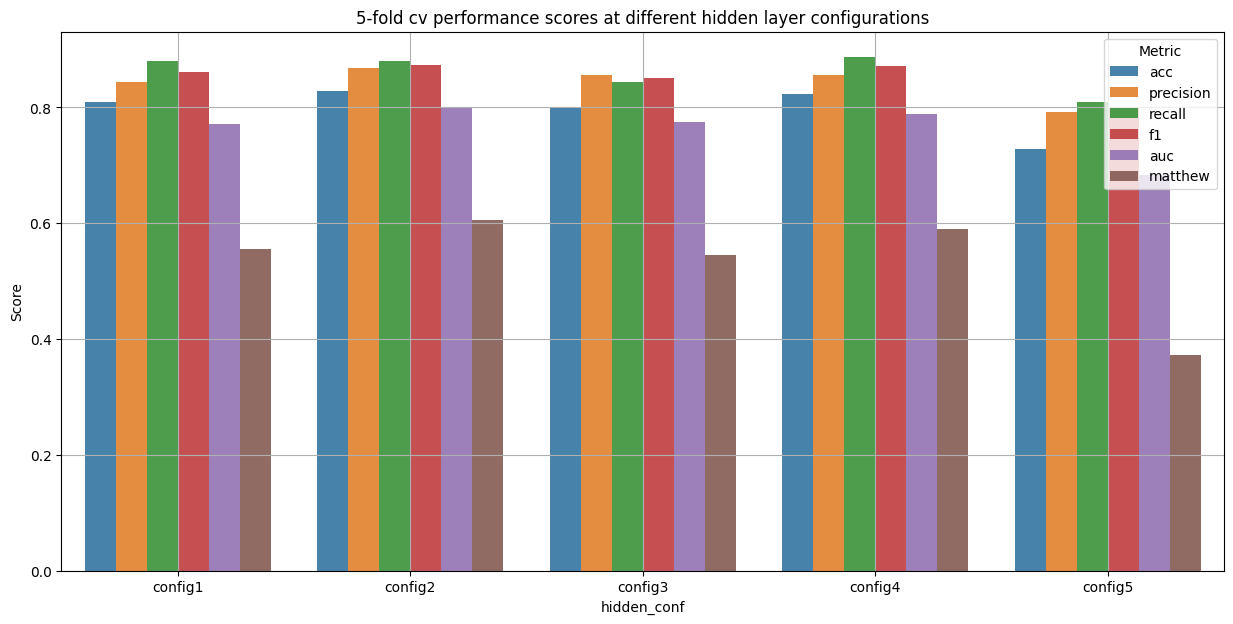

In [30]:
fig, ax = plt.subplots(figsize=(15, 7))
sns.barplot(data = df_forPlot,
            x = 'hidden_conf',
            y = 'Score',
            hue = 'Metric',
            alpha= 0.9,
            ax=ax)
plt.grid()
#plt.axvline(x=20, ls="--")
plt.title('5-fold cv performance scores at different hidden layer configurations')

\
If we focus on acc, then we select config2

&nbsp;  
<font color="275bb0">**Use the ANN model with selected hidden layer structure to predict test set**</font>

\
Create an ANN model using selected hidden layer structure from the previous step and fit model on train data.

In [31]:
ann = MLPClassifier(hidden_layer_sizes=(24, 12, 12, 6),
                    activation='relu',
                    solver='adam',
                    random_state=1234, # random number generation for weights and bias initialization
                    # batch_size = 25,
                    max_iter = 400,
                    learning_rate='adaptive')
ann.fit(X=X_train_sc, y=y_train)

MLPClassifier(hidden_layer_sizes=(24, 12, 12, 6), learning_rate='adaptive',
              max_iter=400, random_state=1234)

\
Use above ANN model to predict test set:

In [32]:
y_pred_test = ann.predict(X_test_sc)
y_pred_test

array([1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1])

\
Display confusion matrix:

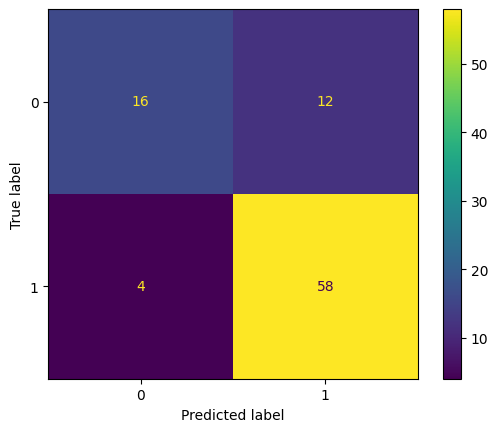

In [33]:
conf_mat = metrics.confusion_matrix(y_test, y_pred_test, labels=[0, 1])
metrics.ConfusionMatrixDisplay(conf_mat,
                               display_labels=[0, 1]).plot()

\
Evaluate model performance scores based on test set:

In [34]:
acc = metrics.accuracy_score(y_test, y_pred_test)
precision = metrics.precision_score(y_test, y_pred_test)
recall = metrics.recall_score(y_test, y_pred_test)
f1 = metrics.f1_score(y_test, y_pred_test)
matw = metrics.matthews_corrcoef(y_test, y_pred_test)
auc = metrics.roc_auc_score(y_test, y_pred_test)

print(f"Test set performance scores:\n"
      f"accuracy: {acc:.2f}\n"
      f"precision: {precision:.2f}\n"
      f"recall: {recall:.2f}\n"
      f"f1: {f1:.2f}\n"
      f"auc: {auc:.2f}\n"
      f"Matthew's corr coef: {matw:.2f}\n"
     )

Test set performance scores:
accuracy: 0.82
precision: 0.83
recall: 0.94
f1: 0.88
auc: 0.75
Matthew's corr coef: 0.56



&nbsp;  
<font color="275bb0">**Tensorflow with Keras API**</font>

In [38]:
# %pip install keras
%pip install tensorflow

UsageError: Line magic function `%python` not found (But cell magic `%%python` exists, did you mean that instead?).


In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint

# Define checkpoint callback to save the model at each epoch
checkpoint_callback = ModelCheckpoint('best_model_epoch_{epoch:02d}.h5', save_best_only=False, save_weights_only=False)

# Split the dataset into training and validation sets (80% train, 20% validation)
X_train_sc, X_val_sc, y_train, y_val = train_test_split(X_train_sc, y_train, test_size=0.2, random_state=1234, stratify=y_train)

# Define the model
model = Sequential([
    Dense(24, activation='relu', input_shape=(X_train_sc.shape[1],)),
    Dense(12, activation='relu'),
    Dense(12, activation='relu'),
    Dense(6, activation='relu'),
    Dense(1, activation='sigmoid')  # Use softmax if multi-class classification
])

# Compile the model
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model with validation data
history = model.fit(X_train_sc, y_train.astype(int), epochs=200, batch_size=20,
                    validation_data=(X_val_sc, y_val.astype(int)), verbose=1,
                    callbacks=[checkpoint_callback])

# Extract loss and accuracy history
history_dict = history.history


ModuleNotFoundError: No module named 'tensorflow'

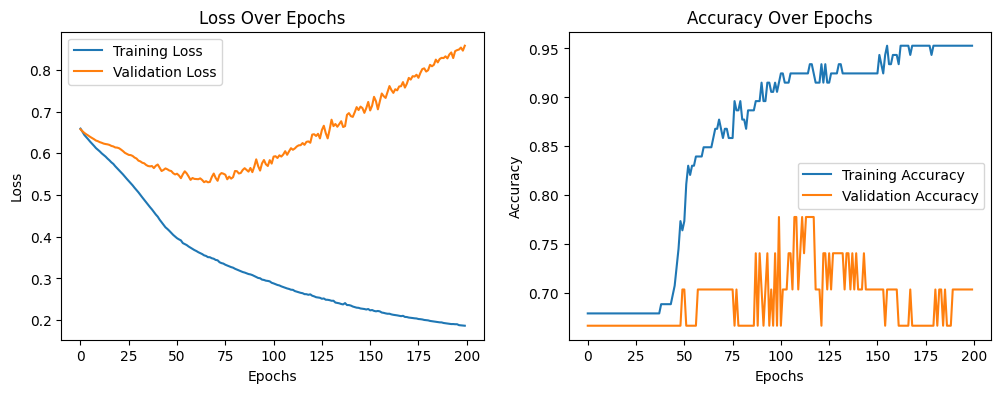

In [140]:
# Plot the loss and accuracy
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Plot loss
axs[0].plot(history_dict['loss'], label='Training Loss')
axs[0].plot(history_dict['val_loss'], label='Validation Loss')
axs[0].set_title('Loss Over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()

# Plot accuracy
axs[1].plot(history_dict['accuracy'], label='Training Accuracy')
axs[1].plot(history_dict['val_accuracy'], label='Validation Accuracy')
axs[1].set_title('Accuracy Over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.show()

&nbsp;  
If I select model at epoch 50:

In [141]:
from tensorflow.keras.models import load_model

# Load the saved model from epoch 50
model_epoch_50 = load_model('best_model_epoch_70.h5')

In [142]:
y_pred_kras = model_epoch_50.predict(X_test_sc)
y_pred_kras_labels = (y_pred_kras > 0.5).astype(int)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


In [143]:
acc = metrics.accuracy_score(y_pred_kras_labels, y_pred_test)
precision = metrics.precision_score(y_pred_kras_labels, y_pred_test)
recall = metrics.recall_score(y_pred_kras_labels, y_pred_test)
f1 = metrics.f1_score(y_pred_kras_labels, y_pred_test)
matw = metrics.matthews_corrcoef(y_pred_kras_labels, y_pred_test)
auc = metrics.roc_auc_score(y_pred_kras_labels, y_pred_test)

In [144]:
print(f"Test set performance scores:\n"
      f"accuracy: {acc:.2f}\n"
      f"precision: {precision:.2f}\n"
      f"recall: {recall:.2f}\n"
      f"f1: {f1:.2f}\n"
      f"auc: {auc:.2f}\n"
      f"Matthew's corr coef: {matw:.2f}\n"
     )

Test set performance scores:
accuracy: 0.71
precision: 0.97
recall: 0.71
f1: 0.82
auc: 0.71
Matthew's corr coef: 0.24



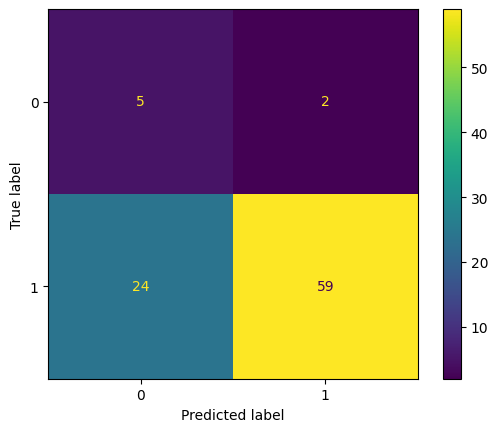

In [145]:
conf_mat = metrics.confusion_matrix(y_pred_kras_labels, y_pred_test, labels=[0, 1])
metrics.ConfusionMatrixDisplay(conf_mat,
                               display_labels=[0, 1]).plot()

&nbsp;  
<font color="275bb0">**A Neural Network Playground**</font>

In [1]:
%%html
<iframe src="https://playground.tensorflow.org" width="1200" height="1000"></iframe>